In [1]:
# 1. Path

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_ROOT = REPO_ROOT / 'data' / 'raw' / 'COVID-19_Radiography_Dataset'
sys.path.insert(0, str(REPO_ROOT / 'src'))

assert DATA_ROOT.exists(), f'not found at {DATA_ROOT}; check the unzip path'
sorted(p.name for p in DATA_ROOT.iterdir())


['COVID',
 'COVID.metadata.xlsx',
 'Lung_Opacity',
 'Lung_Opacity.metadata.xlsx',
 'Normal',
 'Normal.metadata.xlsx',
 'README.md.txt',
 'Viral Pneumonia',
 'Viral Pneumonia.metadata.xlsx']

In [2]:
# 2. verify against the spec's assumptions

from PIL import Image
from covid_xray.config import CLASS_NAMES

for class_name in CLASS_NAMES:
    images = sorted((DATA_ROOT / class_name / "images").glob("*.png"))
    masks  = sorted((DATA_ROOT / class_name / "masks").glob("*.png"))
    with Image.open(images[0]) as im, Image.open(masks[0]) as mk:
        print(f"{class_name:18s} images={len(images):6d} masks={len(masks):6d} "
              f"image_size={im.size} image_mode={im.mode} "
              f"mask_size={mk.size} mask_mode={mk.mode}")


COVID              images=  3616 masks=  3616 image_size=(299, 299) image_mode=L mask_size=(256, 256) mask_mode=RGB
Lung_Opacity       images=  6012 masks=  6012 image_size=(299, 299) image_mode=L mask_size=(256, 256) mask_mode=RGB
Normal             images= 10192 masks= 10192 image_size=(299, 299) image_mode=L mask_size=(256, 256) mask_mode=RGB
Viral Pneumonia    images=  1345 masks=  1345 image_size=(299, 299) image_mode=L mask_size=(256, 256) mask_mode=RGB


In [3]:
# 3. Scan and Hash

from covid_xray.dedup import scan_dataset

catalogue = scan_dataset(DATA_ROOT)
print(f"{len(catalogue)} images catalogued")
catalogue.groupby("class_name").size()


21165 images catalogued


class_name
COVID               3616
Lung_Opacity        6012
Normal             10192
Viral Pneumonia     1345
dtype: int64

In [17]:
import importlib
import covid_xray.dedup

importlib.reload(covid_xray.dedup)
from covid_xray.dedup import find_duplicate_groups, drop_duplicates, summarise_duplicates

print(find_duplicate_groups.__defaults__)   # expect (1,)


(1,)


In [18]:
# 4. Find and remove duplicates

from covid_xray.dedup import find_duplicate_groups, drop_duplicates, summarise_duplicates

groups = find_duplicate_groups(catalogue)   # default max_distance=1, see dedup.py
summary = summarise_duplicates(catalogue, groups)
print(summary)

kept, removed = drop_duplicates(catalogue, groups)
(REPO_ROOT / 'reports').mkdir(exist_ok=True)
removed.drop(columns=["phash"]).to_csv(REPO_ROOT / "reports" / "duplicates.csv", index=False)
print(f"{len(catalogue)} -> {len(kept)} after de-duplication")


{'n_groups': 178, 'n_removed': 223, 'n_within_class': 178, 'n_cross_class': 0, 'max_group_size': 7}
21165 -> 20942 after de-duplication


In [19]:
# from covid_xray.dedup import find_duplicate_groups, summarise_duplicates

# # MD5 exact pixel matches: unambiguous, no threshold involved.
# md5_groups = [sorted(map(int, pos))
#               for _, pos in catalogue.groupby("md5").indices.items() if len(pos) > 1]
# print(f"{'md5 exact':<14}", summarise_duplicates(catalogue, md5_groups))

# for d in (0, 1, 2, 3, 5, 8):
#     groups_d = find_duplicate_groups(catalogue, max_distance=d)
#     print(f"{'phash <= ' + str(d):<14}", summarise_duplicates(catalogue, groups_d))


17 cross-class groups at phash <= 3 (expect ~17)


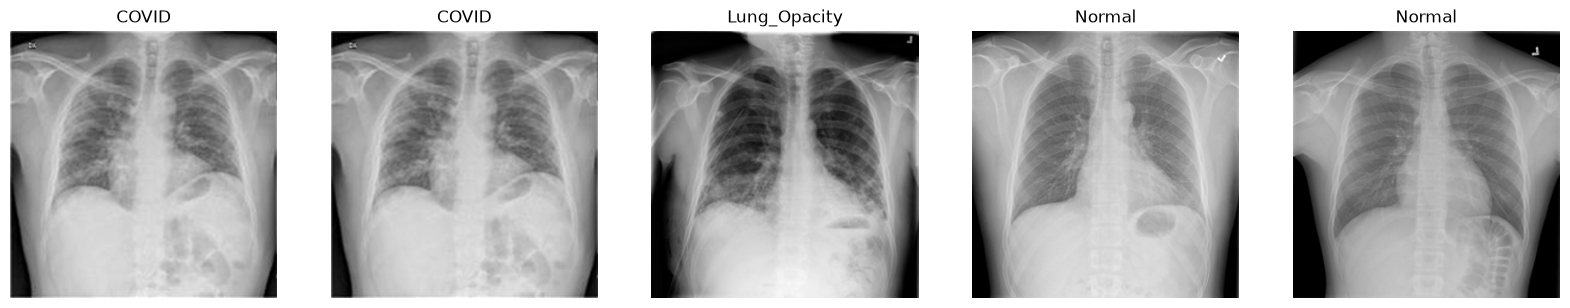

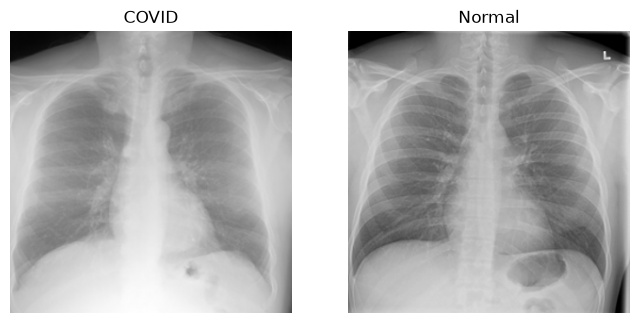

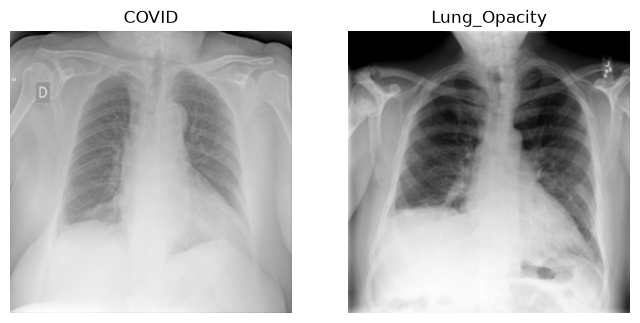

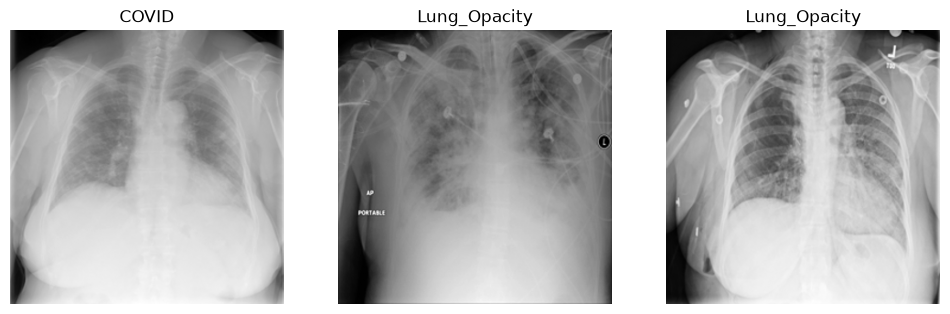

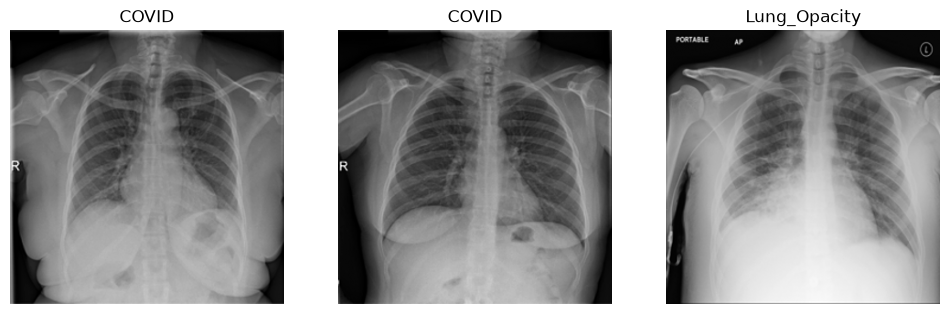

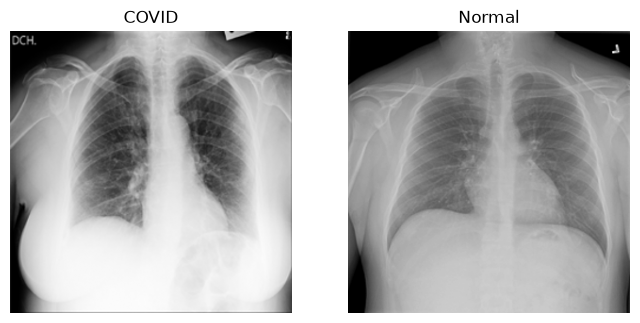

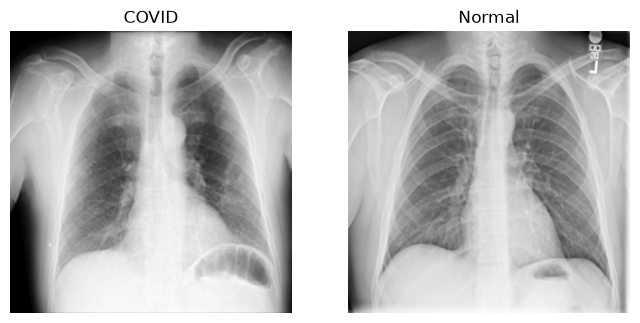

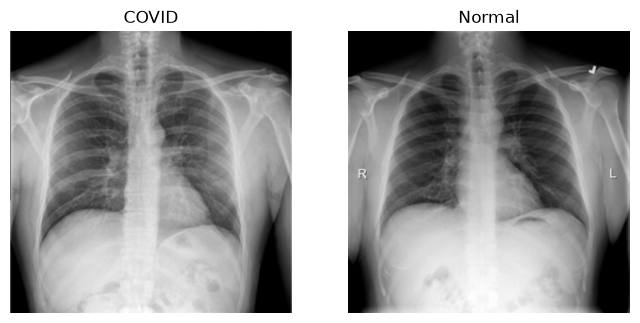

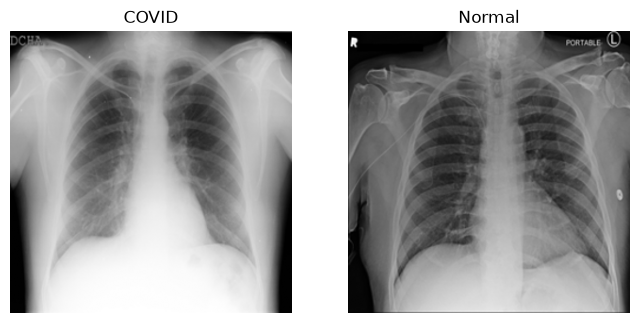

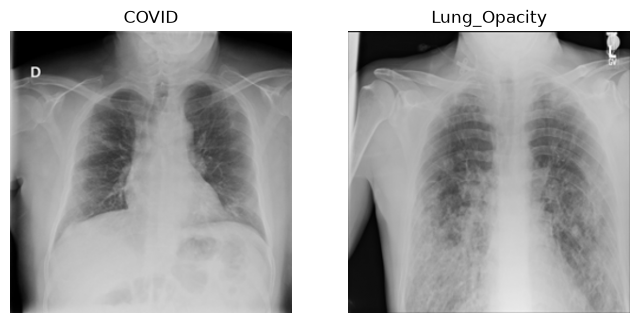

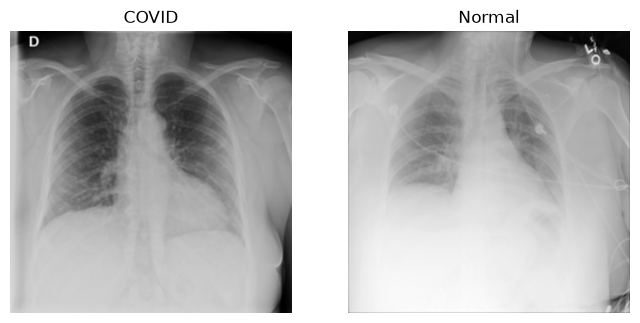

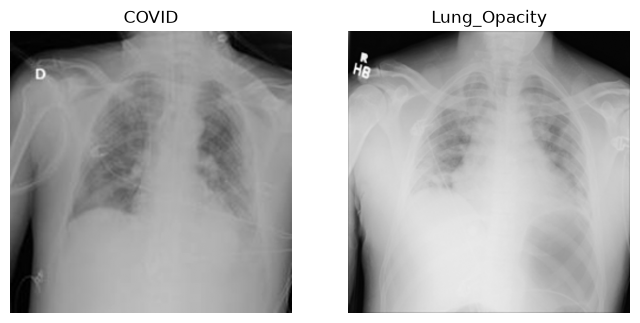

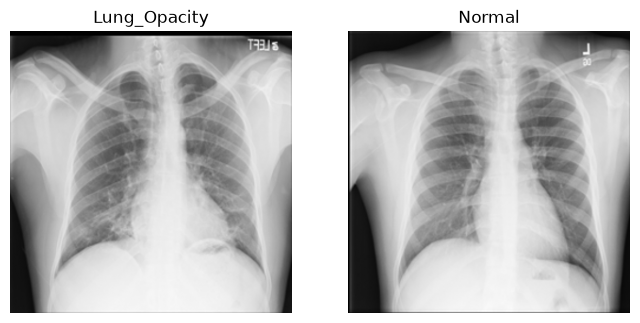

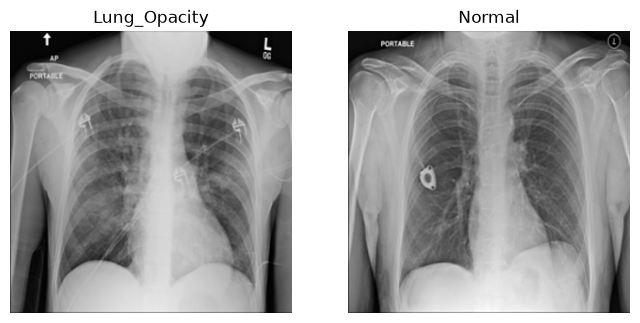

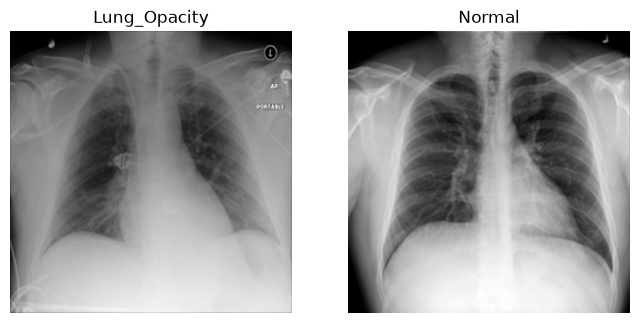

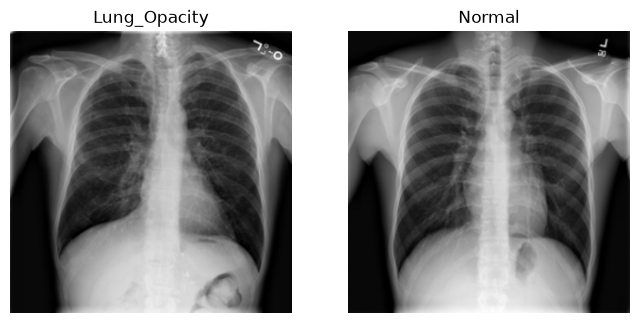

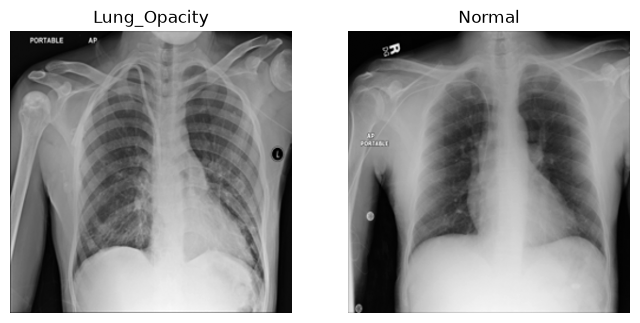

In [20]:
import numpy as np
import matplotlib.pyplot as plt

cross3 = [g for g in find_duplicate_groups(catalogue, max_distance=3)
          if catalogue.iloc[g]["class_name"].nunique() > 1]
print(f"{len(cross3)} cross-class groups at phash <= 3 (expect ~17)")

for group in cross3:
    rows = catalogue.iloc[group]
    fig, axes = plt.subplots(1, len(rows), figsize=(4 * len(rows), 4))
    for ax, (_, row) in zip(np.atleast_1d(axes), rows.iterrows()):
        ax.imshow(plt.imread(DATA_ROOT / row["path"]), cmap="gray")
        ax.set_title(row["class_name"]); ax.axis("off")
    plt.show()


In [21]:
# 5. Eyeball the cross-class duplicates(label noise)


cross = [g for g in groups if catalogue.iloc[g]["class_name"].nunique() > 1]
print(f"{len(cross)} cross-class duplicate groups")

for group in cross[:3]:
    rows = catalogue.iloc[group]
    fig, axes = plt.subplots(1, len(rows), figsize=(4 * len(rows), 4))
    axes = [axes] if len(rows) == 1 else axes
    for ax, (_, row) in zip(axes, rows.iterrows()):
        ax.imshow(plt.imread(DATA_ROOT / row["path"]), cmap="gray")
        ax.set_title(row["class_name"]); ax.axis("off")
    plt.show()


0 cross-class duplicate groups


In [22]:
# 6. Split and write manifests

from covid_xray.splits import stratified_split, write_manifests, class_distribution

SEED = 42
split_df = stratified_split(kept, seed=SEED)
written = write_manifests(split_df, REPO_ROOT / "data" / "splits")

distribution = class_distribution(split_df)
print(distribution)
distribution.to_csv(REPO_ROOT / "reports" / "class_distribution.csv")
written


split            train   val  test
class_name                        
COVID             2381   510   511
Lung_Opacity      4208   902   902
Normal            7133  1528  1529
Viral Pneumonia    937   201   200


{'train': PosixPath('/home/daniel/Documents/personal/covid-xray-detection/data/splits/train.csv'),
 'val': PosixPath('/home/daniel/Documents/personal/covid-xray-detection/data/splits/val.csv'),
 'test': PosixPath('/home/daniel/Documents/personal/covid-xray-detection/data/splits/test.csv')}

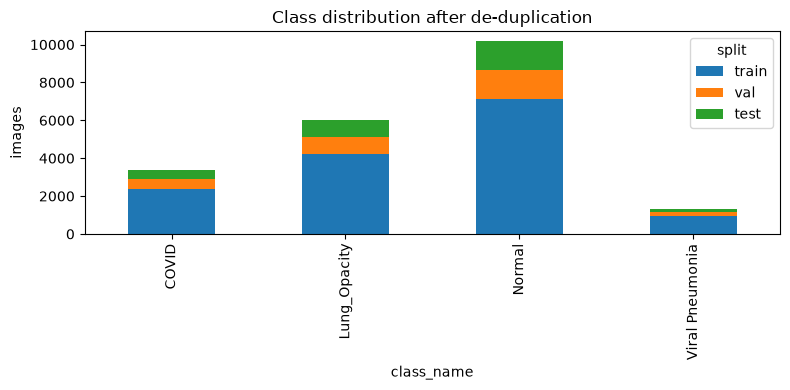

In [23]:
# 7. Figure

ax = distribution.plot(kind="bar", stacked=True, figsize=(8, 4))
ax.set_ylabel("images"); ax.set_title("Class distribution after de-duplication")
plt.tight_layout()
plt.savefig(REPO_ROOT / "reports" / "figures" / "class_distribution.png", dpi=150)
plt.show()


In [24]:
# 8. Verify no leakage

import pandas as pd
frames = {s: pd.read_csv(REPO_ROOT / 'data' / 'splits' / f'{s}.csv') for s in ['train','val','test']}
paths  = {s: set(d['path']) for s, d in frames.items()}
assert not (paths['train'] & paths['test']), 'train/test overlap'
assert not (paths['train'] & paths['val']),  'train/val overlap'
assert not (paths['val']   & paths['test']), 'val/test overlap'
for s, d in frames.items():
    print(s, len(d), dict(d['class_name'].value_counts()))


train 14659 {'Normal': np.int64(7133), 'Lung_Opacity': np.int64(4208), 'COVID': np.int64(2381), 'Viral Pneumonia': np.int64(937)}
val 3141 {'Normal': np.int64(1528), 'Lung_Opacity': np.int64(902), 'COVID': np.int64(510), 'Viral Pneumonia': np.int64(201)}
test 3142 {'Normal': np.int64(1529), 'Lung_Opacity': np.int64(902), 'COVID': np.int64(511), 'Viral Pneumonia': np.int64(200)}
